In [1]:
import mujoco
import mujoco.viewer
import numpy as np

# Define a simple arena in MJCF XML
ARENA_XML = """
<mujoco>
  <option timestep="0.01"/>
  <worldbody>
    <light diffuse=".5 .5 .5" pos="0 0 5" dir="0 0 -1"/>
    <geom type="plane" size="5 5 0.1" rgba="0.8 0.8 0.8 1"/>
    
    <!-- boundary walls -->
    <geom type="box" size="5 0.1 0.5" pos="0 5 0.5" rgba="0.3 0.3 0.3 1"/>
    <geom type="box" size="5 0.1 0.5" pos="0 -5 0.5" rgba="0.3 0.3 0.3 1"/>
    <geom type="box" size="0.1 5 0.5" pos="5 0 0.5" rgba="0.3 0.3 0.3 1"/>
    <geom type="box" size="0.1 5 0.5" pos="-5 0 0.5" rgba="0.3 0.3 0.3 1"/>

    <!-- agent: a small cylinder with a hinge for steering -->
    <body name="agent" pos="0 0 0.15">
      <joint name="agent_x" type="slide" axis="1 0 0"/>
      <joint name="agent_y" type="slide" axis="0 1 0"/>
      <joint name="agent_yaw" type="hinge" axis="0 0 1"/>
      <geom type="cylinder" size="0.15 0.1" rgba="0 0.5 1 1"/>
      <!-- onboard camera for first-person RGB -->
      <camera name="agent_cam" pos="0 0 0.2" 
              xyaxes="1 0 0 0 0 1" fovy="90"/>
    </body>
  </worldbody>

  <actuator>
    <velocity name="forward" joint="agent_x" kv="10"/>
    <velocity name="strafe" joint="agent_y" kv="10"/>
    <velocity name="turn" joint="agent_yaw" kv="5"/>
  </actuator>
</mujoco>
"""

model = mujoco.MjModel.from_xml_string(ARENA_XML)
data = mujoco.MjData(model)

In [2]:
# First-person RGB rendering
renderer = mujoco.Renderer(model, height=64, width=64)

def get_agent_view(renderer, data):
    renderer.update_scene(data, camera="agent_cam")
    return renderer.render()

# Top-down camera for debugging/visualization
TOP_CAM_XML = """<camera name="top_down" pos="0 0 12" 
                  xyaxes="1 0 0 0 1 0" fovy="60"/>"""
# Add this to your XML worldbody

def get_topdown_view(renderer, data):
    renderer.update_scene(data, camera="top_down")
    return renderer.render()

In [3]:
def get_agent_pose(data):
    x = data.qpos[0]
    y = data.qpos[1]
    yaw = data.qpos[2]
    return x, y, yaw

def command_agent(data, forward_vel, turn_vel):
    """Set velocity commands. Call mujoco.mj_step() after."""
    heading = data.qpos[2]
    data.ctrl[0] = forward_vel * np.cos(heading)  # x velocity
    data.ctrl[1] = forward_vel * np.sin(heading)  # y velocity
    data.ctrl[2] = turn_vel                         # yaw rate

In [4]:
def generate_arena_xml(room_half_size=5, obstacles=None):
    """Generate MJCF XML with specified obstacles.
    
    obstacles: list of (x, y, half_size_x, half_size_y) tuples
    """
    obs_xml = ""
    if obstacles:
        for i, (ox, oy, sx, sy) in enumerate(obstacles):
            obs_xml += f"""
            <geom name="obs_{i}" type="box" 
                  size="{sx} {sy} 0.5" pos="{ox} {oy} 0.5" 
                  rgba="0.6 0.2 0.2 1"/>"""
    # ... insert into full XML template
    return xml_string

def make_open_arena():
    return generate_arena_xml(obstacles=[])

def make_cluttered_room(num_obs=10, seed=42):
    rng = np.random.RandomState(seed)
    obstacles = []
    for _ in range(num_obs):
        ox = rng.uniform(-4, 4)
        oy = rng.uniform(-4, 4)
        sx = rng.uniform(0.2, 0.6)
        sy = rng.uniform(0.2, 0.6)
        obstacles.append((ox, oy, sx, sy))
    return generate_arena_xml(obstacles=obstacles)

def make_maze():
    walls = [
        (0, 2, 3, 0.1), (-2, 0, 0.1, 2),
        (2, -1, 0.1, 3), (-1, -3, 2, 0.1),
    ]
    return generate_arena_xml(obstacles=walls)

In [5]:
class OccupancyGrid:
    def __init__(self, world_half_size=5, resolution=0.1):
        self.resolution = resolution
        self.half_size = world_half_size
        self.grid_dim = int(2 * world_half_size / resolution)
        self.grid = np.zeros((self.grid_dim, self.grid_dim), dtype=np.int8)

    def world_to_grid(self, x, y):
        gx = int((x + self.half_size) / self.resolution)
        gy = int((y + self.half_size) / self.resolution)
        return np.clip(gx, 0, self.grid_dim-1), np.clip(gy, 0, self.grid_dim-1)

    def update(self, model, data, agent_x, agent_y, agent_yaw,
               fov=np.pi, max_range=3.0, num_rays=60):
        for angle_offset in np.linspace(-fov/2, fov/2, num_rays):
            angle = agent_yaw + angle_offset
            direction = np.array([np.cos(angle), np.sin(angle), 0.0])
            origin = np.array([agent_x, agent_y, 0.2])

            geom_id = np.array([-1], dtype=np.int32)
            dist = mujoco.mj_ray(
                model, data, origin, direction,
                None, 1, -1, geom_id
            )

            hit_range = dist if dist > 0 else max_range
            hit_range = min(hit_range, max_range)

            for d in np.arange(0, hit_range, self.resolution):
                px = agent_x + d * np.cos(angle)
                py = agent_y + d * np.sin(angle)
                gx, gy = self.world_to_grid(px, py)
                self.grid[gx, gy] = 1  # free

            if dist > 0 and dist < max_range:
                px = agent_x + dist * np.cos(angle)
                py = agent_y + dist * np.sin(angle)
                gx, gy = self.world_to_grid(px, py)
                self.grid[gx, gy] = -1  # obstacle

In [7]:
import matplotlib.pyplot as plt

def render_state(rgb_obs, occ_grid, trail, save_path=None):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(rgb_obs)
    axes[0].set_title("Agent First-Person View")

    display = occ_grid.grid.T
    axes[1].imshow(display, cmap="RdYlGn", origin="lower", vmin=-1, vmax=1)
    axes[1].set_title("Occupancy Grid")

    trail_arr = np.array(trail)
    grid_trail = np.array([occ_grid.world_to_grid(t[0], t[1]) 
                           for t in trail_arr])
    axes[2].imshow(display, cmap="RdYlGn", origin="lower", vmin=-1, vmax=1)
    axes[2].plot(grid_trail[:, 0], grid_trail[:, 1], 'b-', linewidth=0.5)
    axes[2].plot(grid_trail[-1, 0], grid_trail[-1, 1], 'ro', markersize=4)
    axes[2].set_title("Trajectory Overlay")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100)
    plt.close()

## Example: Agent rollout with visual input and occupancy map

This example rebuilds a scene with both `agent_cam` and `top_down` cameras, then uses your existing functions:

- `command_agent` to move the agent
- `get_agent_pose` to read state
- `get_agent_view` and `get_topdown_view` for visual observations
- `OccupancyGrid.update` to maintain a local map
- `render_state` to save triplet visualizations over time

Run this cell after the previous function-definition cells.

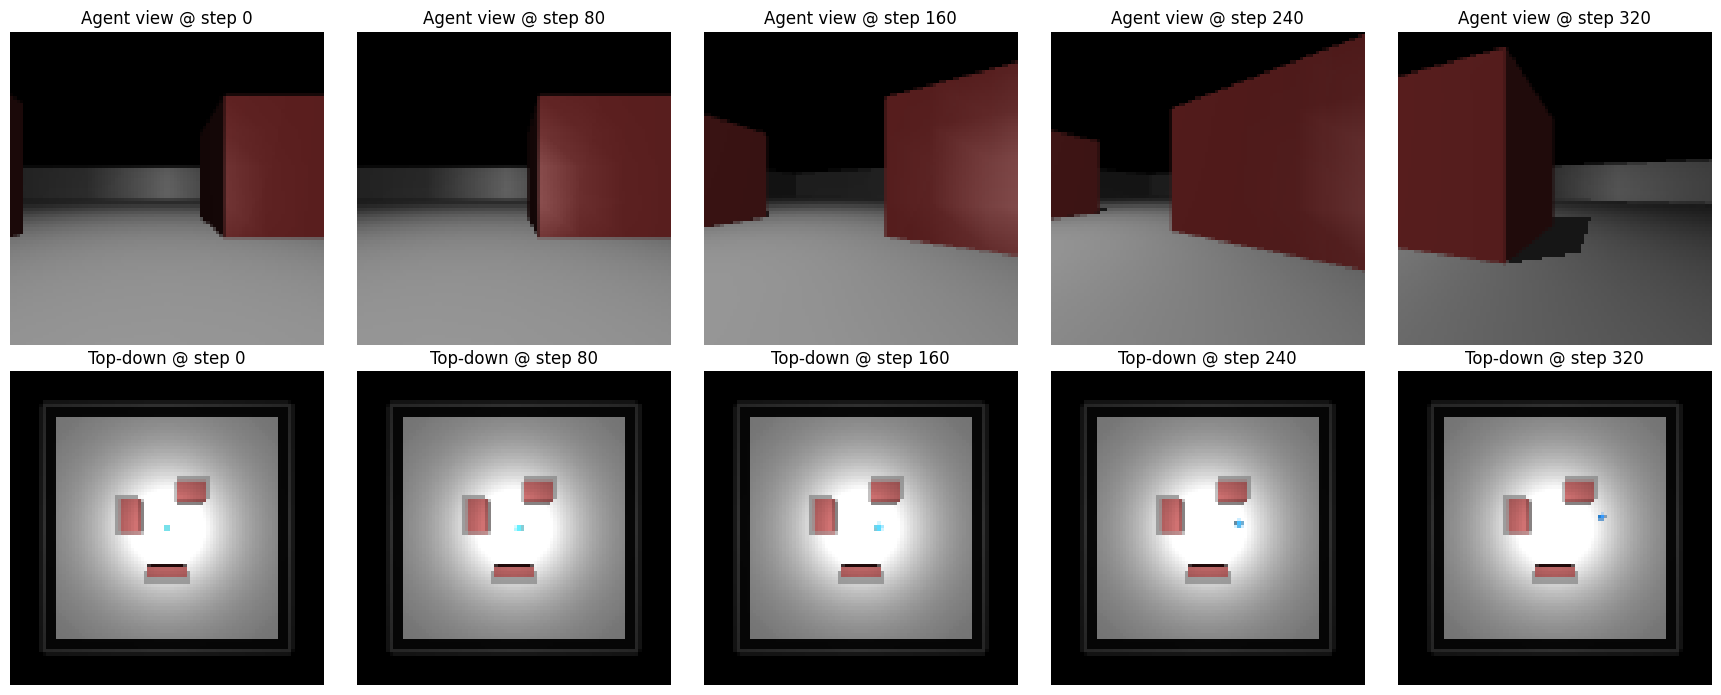

Final pose: x=2.67, y=0.72
Saved files: state_000.png, state_080.png, state_160.png, ...


In [8]:
# Rebuild the model so both cameras exist in the scene.
SCENE_XML = """
<mujoco>
  <option timestep="0.01"/>
  <worldbody>
    <light diffuse=".6 .6 .6" pos="0 0 6" dir="0 0 -1"/>
    <geom type="plane" size="5 5 0.1" rgba="0.85 0.85 0.85 1"/>

    <!-- Boundary walls -->
    <geom type="box" size="5 0.1 0.5" pos="0 5 0.5" rgba="0.25 0.25 0.25 1"/>
    <geom type="box" size="5 0.1 0.5" pos="0 -5 0.5" rgba="0.25 0.25 0.25 1"/>
    <geom type="box" size="0.1 5 0.5" pos="5 0 0.5" rgba="0.25 0.25 0.25 1"/>
    <geom type="box" size="0.1 5 0.5" pos="-5 0 0.5" rgba="0.25 0.25 0.25 1"/>

    <!-- A few obstacles -->
    <geom name="obs_0" type="box" size="0.6 0.4 0.5" pos="1.0 1.5 0.5" rgba="0.6 0.2 0.2 1"/>
    <geom name="obs_1" type="box" size="0.4 0.7 0.5" pos="-1.5 0.5 0.5" rgba="0.6 0.2 0.2 1"/>
    <geom name="obs_2" type="box" size="0.8 0.2 0.5" pos="0.0 -1.8 0.5" rgba="0.6 0.2 0.2 1"/>

    <body name="agent" pos="0 0 0.15">
      <joint name="agent_x" type="slide" axis="1 0 0"/>
      <joint name="agent_y" type="slide" axis="0 1 0"/>
      <joint name="agent_yaw" type="hinge" axis="0 0 1"/>
      <geom type="cylinder" size="0.15 0.1" rgba="0 0.5 1 1"/>
      <camera name="agent_cam" pos="0 0 0.2" xyaxes="1 0 0 0 0 1" fovy="90"/>
    </body>

    <camera name="top_down" pos="0 0 12" xyaxes="1 0 0 0 1 0" fovy="60"/>
  </worldbody>

  <actuator>
    <velocity name="forward" joint="agent_x" kv="10"/>
    <velocity name="strafe" joint="agent_y" kv="10"/>
    <velocity name="turn" joint="agent_yaw" kv="5"/>
  </actuator>
</mujoco>
"""

model = mujoco.MjModel.from_xml_string(SCENE_XML)
data = mujoco.MjData(model)
renderer = mujoco.Renderer(model, height=96, width=96)

occ_grid = OccupancyGrid(world_half_size=5, resolution=0.1)
trail = []
rgb_snapshots = []
topdown_snapshots = []

# Rollout with a simple piecewise control policy.
for t in range(400):
    if t < 100:
        forward_vel, turn_vel = 1.2, 0.0
    elif t < 200:
        forward_vel, turn_vel = 1.0, 0.8
    elif t < 300:
        forward_vel, turn_vel = 1.1, -0.6
    else:
        forward_vel, turn_vel = 0.8, 0.4

    command_agent(data, forward_vel, turn_vel)
    mujoco.mj_step(model, data)

    x, y, yaw = get_agent_pose(data)
    trail.append((x, y))

    occ_grid.update(
        model, data,
        agent_x=x,
        agent_y=y,
        agent_yaw=yaw,
        fov=np.pi * 0.9,
        max_range=3.0,
        num_rays=72,
    )

    if t % 80 == 0:
        rgb = get_agent_view(renderer, data)
        top = get_topdown_view(renderer, data)
        rgb_snapshots.append(rgb.copy())
        topdown_snapshots.append(top.copy())
        render_state(rgb, occ_grid, trail, save_path=f"state_{t:03d}.png")

# Visualize saved snapshots from both cameras.
n = len(rgb_snapshots)
fig, axes = plt.subplots(2, n, figsize=(3.5 * n, 7))
if n == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for i in range(n):
    axes[0, i].imshow(rgb_snapshots[i])
    axes[0, i].set_title(f"Agent view @ step {i*80}")
    axes[0, i].axis("off")

    axes[1, i].imshow(topdown_snapshots[i])
    axes[1, i].set_title(f"Top-down @ step {i*80}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

print(f"Final pose: x={trail[-1][0]:.2f}, y={trail[-1][1]:.2f}")
print("Saved files: state_000.png, state_080.png, state_160.png, ...")

## Faster trail logging (no top-down rendering)

Yes. If you only need trajectory plotting, avoid `get_topdown_view(...)` and skip storing image frames.

This version preallocates a NumPy array for positions and plots the path directly in world coordinates with Matplotlib.

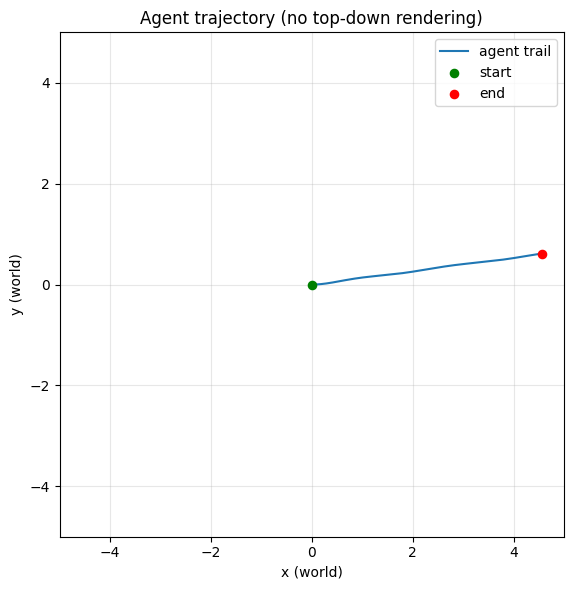

Logged 600 points. Final pose: x=4.55, y=0.61


In [9]:
# Fast rollout: store only (x, y) trail and plot directly.
steps = 600
trail_xy = np.empty((steps, 2), dtype=np.float32)

# Optional: fresh state reset before timing/rollout.
mujoco.mj_resetData(model, data)

for t in range(steps):
    # Example control policy (replace with your planner/policy).
    forward_vel = 1.0
    turn_vel = 0.4 * np.sin(t * 0.03)

    command_agent(data, forward_vel, turn_vel)
    mujoco.mj_step(model, data)

    # Faster than appending Python tuples: write directly into NumPy array.
    trail_xy[t, 0] = data.qpos[0]
    trail_xy[t, 1] = data.qpos[1]

# Plot in world coordinates (meters), bypassing top-down camera rendering.
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(trail_xy[:, 0], trail_xy[:, 1], color="tab:blue", linewidth=1.5, label="agent trail")
ax.scatter(trail_xy[0, 0], trail_xy[0, 1], c="green", s=35, label="start", zorder=3)
ax.scatter(trail_xy[-1, 0], trail_xy[-1, 1], c="red", s=35, label="end", zorder=3)
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_xlabel("x (world)")
ax.set_ylabel("y (world)")
ax.set_title("Agent trajectory (no top-down rendering)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Logged {steps} points. Final pose: x={trail_xy[-1,0]:.2f}, y={trail_xy[-1,1]:.2f}")